In [1]:
import os
os.chdir('../')

In [2]:
!ls logs/gmdit/bns

s9


2025-09-02 05:14:04.727087: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


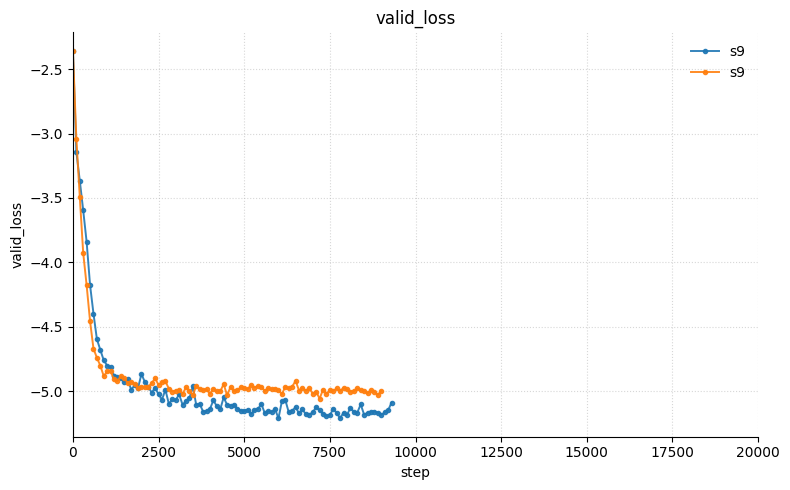

In [3]:
# TensorBoard scalars -> Matplotlib (explicit dirs, tags required; no UI, no error handling)
from tensorboard.backend.event_processing import event_accumulator as ea
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

RUN_DIRS = ['logs/gmdit/bns/s9',
            'logs/gmdit/ds/s9',
            ]
TAGS = ['valid_loss']

# load
metrics = {}  # {tag: {run: (steps, values)}}
for r in RUN_DIRS:
    acc = ea.EventAccumulator(r, size_guidance={ea.SCALARS:0}); acc.Reload()
    for t in acc.Tags()["scalars"]:
        ev = acc.Scalars(t)
        s = np.array([e.step for e in ev]); v = np.array([e.value for e in ev])
        i = np.argsort(s, kind="stable"); s, v = s[i], v[i]      # sort by step
        u, k = np.unique(s, return_index=True); s, v = u, v[k]   # dedup steps
        (metrics.setdefault(t, {}))[r] = (s, v)

if not TAGS:
    print("Available tags:"); 
    for t in sorted(metrics.keys()): print(" •", t)
else:
    for t in TAGS:
        if t not in metrics: continue
        fig, ax = plt.subplots(figsize=(8,5))
        for r,(s,v) in metrics[t].items():
            ax.plot(s, v, '-o', markersize=3, linewidth=1.4, alpha=0.9, label=Path(r).name)
        ax.set_title(t)
        ax.set_xlabel("step"); ax.set_ylabel(t.split("/")[-1])
        ax.grid(True, linestyle=":", alpha=0.5); ax.margins(x=0.02)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        if len(metrics[t])>1: ax.legend(frameon=False)
        plt.xlim([0, 20*1000]); plt.tight_layout(); plt.show()


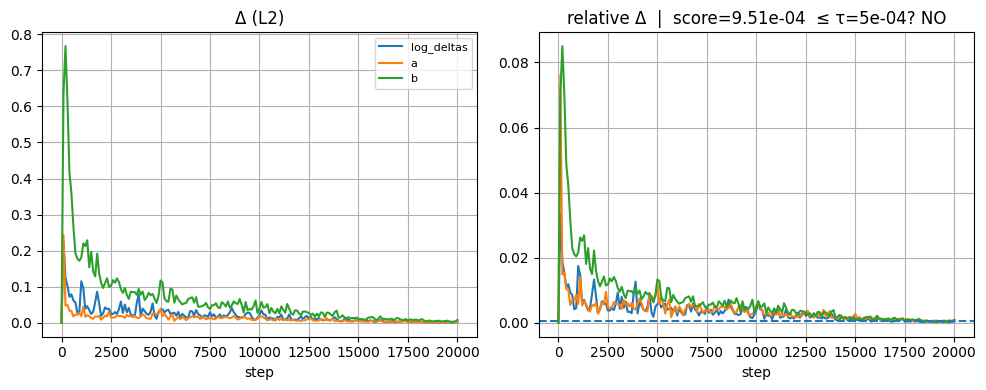

In [21]:
# ✅ 최소버전: 왼쪽=Δ(L2), 오른쪽=relative Δ (양옆 플롯) + 최근 K창 score
import os, torch, matplotlib.pyplot as plt
from collections import defaultdict

DIR = "logs/dit/bns/try2/s9"
TAU, K = 5e-4, 5               # 임계값, 창 크기
EPS = 1e-12

fs = sorted([(int(f[5:-3]), f) for f in os.listdir(DIR) if f.startswith("step_") and f.endswith(".pt")])
xs, dabs, drel = defaultdict(list), defaultdict(list), defaultdict(list)
prev = None

for st, name in fs:
    s = torch.load(f"{DIR}/{name}", map_location="cpu", weights_only=False); s = s.get("solver_state_dict", s)
    cur = {k: v.detach().float().view(-1).cpu() for k, v in s.items() if torch.is_tensor(v)}
    if prev is None:
        for k in cur: xs[k].append(st); dabs[k].append(0.0); drel[k].append(0.0)
    else:
        for k, a in cur.items():
            if k not in prev: xs[k].append(st); dabs[k].append(0.0); drel[k].append(0.0); continue
            b = prev[k]; d = a - b
            xs[k].append(st)
            dabs[k].append(d.norm().item())
            drel[k].append(d.norm().item() / max(a.norm().item(), b.norm().item(), EPS))
    prev = cur

score = max((max(v[-K:]) if v else 1.0) for v in drel.values())
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharex=False)

for k in xs: ax1.plot(xs[k], dabs[k], label=k)
ax1.set_title("Δ (L2)"); ax1.set_xlabel("step"); ax1.grid(True)

for k in xs: ax2.plot(xs[k], drel[k], label=k)
ax2.axhline(TAU, ls="--"); ax2.set_title(f"relative Δ  |  score={score:.2e}  ≤ τ={TAU:.0e}? {'YES' if score<=TAU else 'NO'}")
ax2.set_xlabel("step"); ax2.grid(True)

ax1.legend(fontsize=8, loc="best")
plt.tight_layout(); plt.show()
